### Instructions

This notebook collects and plots results for DRO-RoBAS experiments. It assumes each method has been run on 0, 10% and 20% of contamination levels.

### Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/tmp/dcs-tmp.u1604520/ipykernel_1559642/1313304466.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### Useful functions

In [2]:
def process(experiment_dir, dgp, contamination, trim=False):
    results_df = pd.read_csv(experiment_dir/ "results.csv", index_col=["uuid", "replication"])
    results_df = results_df.loc[(results_df["contamination"] == contamination) & (results_df["dgp"] == dgp)]
    if trim:
        results_df = results_df[results_df['epsilon'] < 0.2]  # where to trim the epsilons, adjust accordingly if needed
    gb = results_df.groupby(by=["algorithm", "epsilon", "inference"])
    agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    })
    return agg_df

In [3]:
def plot_df(df, dgp: str, algorithm: str, label: str, axis, shp: str,  marker=False):
    # get a dataframe for each posterior
    df = df.loc[algorithm, :]
    # # mean of variances + variance of means
    bootstrap_var = df["var_cost"]["mean"] + df["mean_cost"]["var"]
    # plot mean-variance trade-off
    axis.plot(bootstrap_var, df["mean_cost"]["mean"], marker=shp, linestyle='solid', label=label)
    # set title and label epsilon
    axis.set_title(f"{dgp}")
    axis.set_xlabel("out-of-sample variance")
    if dgp == (r'$\eta =$' + '0.0'):
        axis.set_ylabel("out-of-sample mean")
        axis.legend()
    if marker:
        for i, epsilon in enumerate(df.index.get_level_values("epsilon")):
            if i % 4 == 0:
                axis.text(bootstrap_var[epsilon], df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        # if (i+2) % 4 == 0:
        #     axis.text(empirical_bootstrap_var[epsilon], empirical_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

### Set experiment directories for each method (or group of methods) for one DGP

In [4]:
experiment_path_robas = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/bimodal_robas")  # Where RoBAS results are stored
experiment_path_kl = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/bimodal_bas_univ") # Where BDRO/DRO-BAS/BDRO-NPL results are stored
experiment_path_emp = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/bimodal_robas") # Where empirical mmd results are stored
experiment_path_bdro_npl = Path("/dcs/pg23/u1604520/misdro/results_kdro/slurm_batches/bimodal_bdro_npl_univ")

In [5]:
results_df = pd.read_csv(experiment_path_bdro_npl/ "results.csv", index_col=["uuid", "replication"])
results_df = results_df.loc[(results_df["contamination"] == 0.0) & (results_df["dgp"] == "bimodal_univariate_gaussian")]

In [6]:
results_df

mean_cost     var_cost  \
uuid                                 replication                           
a14d0503-2773-4206-863f-c74bb31075db 0            92.888766  1923.723426   
                                     1            91.869064  2128.621446   
                                     2            90.708102  2655.590442   
                                     3            90.676433  2511.360835   
                                     4            90.283675  2398.862533   
...                                                     ...          ...   
397bee37-f982-418d-a029-a557b52244f8 95           87.109679  4974.976513   
                                     96           89.788582  5467.393549   
                                     97           87.603913  4075.154328   
                                     98           87.049459  4251.766780   
                                     99           92.790115  5576.669550   

                                                              solution  \
uuid                                 replication                         
a14d0503-2773-4206-863f-c74bb31075db 0             [52.67175536761595]   
                                     1             [52.88924385399498]   
                                     2            [55.019862673877746]   
                                     3             [54.51367787257334]   
                                     4            [54.777519897880715]   
...                                                                ...   
397bee37-f982-418d-a029-a557b52244f8 95           [63.126127370496995]   
                                     96             [63.2691709844536]   
                                     97            [58.66878309556431]   
                                     98            [59.84357940040789]   
                                     99             [65.2487249238134]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
a14d0503-2773-4206-863f-c74bb31075db 0            0.000590         0.001803   
                                     1            0.000955         0.003905   
                                     2            0.000882         0.004187   
                                     3            0.001092         0.004382   
                                     4            0.000906         0.003532   
...                                                    ...              ...   
397bee37-f982-418d-a029-a557b52244f8 95           0.000800         0.003258   
                                     96           0.000799         0.003650   
                                     97           0.000892         0.003024   
                                     98           0.000959         0.003442   
                                     99           0.000722         0.003106   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
a14d0503-2773-4206-863f-c74bb31075db 0                  0.006621    8.954867   
                                     1                  0.002728    0.556988   
                                     2                  0.003339    0.595055   
                                     3                  0.003461    0.587850   
                                     4                  0.013195    0.610369   
...                                                          ...         ...   
397bee37-f982-418d-a029-a557b52244f8 95                 0.002270    0.480649   
                                     96                 0.033358    0.506425   
                                     97                 0.002454    0.461713   
                                     98                 0.002166    0.453973   
                                     99                 0.001731    0.444851   

                             

### Plot!

/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:894: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/dcs/pg23/u1604520/.local/lib/python3.11/site-packages/matplotlib/text.py:895: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(s

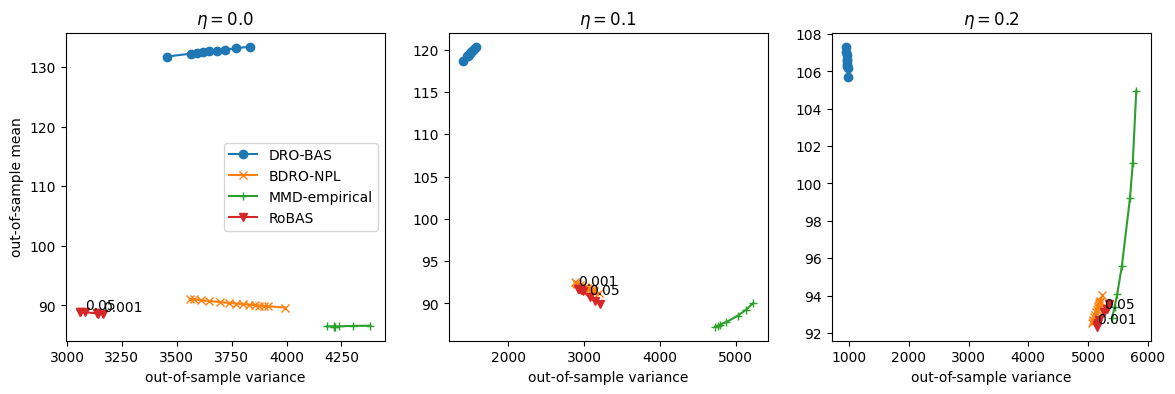

In [10]:
fig, axis = plt.subplots(nrows=1, ncols=3, sharex=False, sharey=False, figsize=(14,4))
contam_levels = [0.0, 0.1, 0.2]  # all contamination levels

# Marker shapes
shp_bas = 'o'
shp_bdro = 's'
shp_bdro_npl = 'x'
shp_emp = '+'
shp_robas = 'v'

for i, contam in enumerate(contam_levels):
    agg_df_kl = process(experiment_path_kl, 'bimodal_univariate_gaussian', contam, trim=True)  
    agg_df_emp = process(experiment_path_emp, 'bimodal_univariate_gaussian', contam,trim=True)
    agg_df_robas = process(experiment_path_robas, 'bimodal_univariate_gaussian', contam,trim=True)
    agg_df_bdro_npl = process(experiment_path_bdro_npl, 'bimodal_univariate_gaussian', contam,trim=True)
    plot_df(agg_df_kl, r'$\eta =$' + f'{contam}', 'kl_dro_bas', 'DRO-BAS', axis[i], shp_bas)
    # plot_df(agg_df_kl, r'$\eta =$' + f'{contam}', 'kl_bdro', 'BDRO', axis[i], shp_bdro, marker=True)
    plot_df(agg_df_bdro_npl, r'$\eta =$' + f'{contam}', 'kl_bdro', 'BDRO-NPL', axis[i], shp_bdro_npl)
    plot_df(agg_df_emp, r'$\eta =$' + f'{contam}', 'empirical_mmd', 'MMD-empirical', axis[i], shp_emp)
    plot_df(agg_df_robas,r'$\eta =$' + f'{contam}', 'dro_bas_mmd', 'RoBAS', axis[i], shp_robas, marker=True)